In [1]:
# Instalación de librerías
#!pip3 install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score,roc_curve, classification_report, confusion_matrix

import matplotlib.pyplot as plt

from xgboost import XGBClassifier


# Configuración de visualizaciones
pd.set_option('display.max_columns', 100)
sns.set_theme(style='darkgrid')


In [3]:
# Carga de datos
df = pd.read_csv('data/loan.csv', low_memory=False)

print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Dimensiones del dataset: (2260668, 145)
Filas: 2,260,668 | Columnas: 145


Se observan 2.260.668 datos de prestamos y 145 variables. 

In [4]:
# Vista general del dataset
print("=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes.value_counts())

print("\n=== INFORMACIÓN GENERAL ===")
df.info(verbose=False, memory_usage='deep')

=== PRIMERAS FILAS ===


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,...,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.0,Apr-2001,1.0,NaN,45.0,9.0,1.0,4341,10.3,34.0,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.0,0.0,0.0,Feb-2019,84.92,Mar-2019,Feb-2019,0.0,...,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.0,Jun-1987,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.0,0.0,0.0,Feb-2019,777.23,Mar-2019,Feb-2019,0.0,...,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,490xx,MI,10.51,0.0,Apr-2011,0.0,NaN,NaN,8.0,0.0,4599,19.1,13.0,w,4787.21,4787.21,353.89,353.89,212.79,141.10,0.0,0.0,0.0,Feb-2019,180.69,Mar-2019,Feb-2019,0.0,...,6.0,7.0,3.0,8.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,136927.0,11749.0,13800.0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,985xx,WA,16.74,0.0,Feb-2006,0.0,NaN,NaN,10.0,0.0,5468,78.1,13.0,w,3831.93,3831.93,286.71,286.71,168.07,118.64,0.0,0.0,0.0,Feb-2019,146.51,Mar-2019,Feb-2019,0.0,...,2.0,3.0,2.0,10.0,0.0,0.0,0.0,3.0,100.0,100.0,0.0,0.0,385183.0,36151.0,5000.0,44984.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidati


=== TIPOS DE DATOS ===
float64    105
object      36
int64        4
Name: count, dtype: int64

=== INFORMACIÓN GENERAL ===


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 5.8 GB


In [5]:
#Agrupamos columnas de interes
df = df.loc[:, ~df.columns.isin(['id', 'member_id'])]

In [6]:
# Revisar distribución de loan_status (variable objetivo)
print("=== DISTRIBUCIÓN DE LOAN STATUS ===")
print(df['loan_status'].value_counts())
print(f"\n% distribución:")
print(df['loan_status'].value_counts(normalize=True).round(3) * 100)

=== DISTRIBUCIÓN DE LOAN STATUS ===
loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

% distribución:
loan_status
Fully Paid                                             46.1
Current                                                40.7
Charged Off                                            11.6
Late (31-120 days)                                      1.0
In Grace Period                                         0.4
Late (16-30 days)             

- Se obserqua que la mayoría de los créditos terminó bien o sigue activo: Fully Paid 46.1% y Current 40.7%, o sea casi 87% no está en mora grave.

Lo preocupante es Charged Off con 11.6%, porque eso significa que el prestamista dio la deuda por pérdida y dejó de esperar pagos.

Los estados Late e In Grace Period son señales de atraso, pero todavía hay margen para recuperación; Default es muy bajo, así que casi todos los casos severos ya quedaron clasificados como Charged Off.

Por otro lado, los registros Does not meet the credit policy, son casos fuera de política crediticia del modelo. No necesariamente préstamos “malos” en el mismo sentido que Charged Off.

In [7]:
# Filtrar solo préstamos con resultado definitivo (excluimos Current y vigentes)
df_modelo = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Crear variable objetivo binaria: 1 = default, 0 = pagó bien
df_modelo['default'] = (df_modelo['loan_status'] == 'Charged Off').astype(int)

print(f"Dataset filtrado: {df_modelo.shape[0]:,} filas")
print(f"\nDistribución de la variable objetivo:")
print(df_modelo['default'].value_counts())
print(f"\n% Default: {df_modelo['default'].mean()*100:.1f}%")

# Muestra de 200k filas para trabajar eficientemente
df_sample = df_modelo.sample(n=200000, random_state=42)
print(f"\nMuestra de trabajo: {df_sample.shape[0]:,} filas")

Dataset filtrado: 1,303,607 filas

Distribución de la variable objetivo:
default
0    1041952
1     261655
Name: count, dtype: int64

% Default: 20.1%



Muestra de trabajo: 200,000 filas


Se filtraron solo los préstamos con resultado definitivo: Fully Paid y Charged Off.

Se descartaron Current y otros estados porque todavía no permiten definir con claridad si el préstamo terminará bien o en default.

La variable objetivo quedó binaria: 0 = pagó bien y 1 = default.

La clase positiva default representa préstamos Charged Off, que es el estado donde el prestamista ya no espera más pagos.

El dataset final tiene 1,303,607 registros, con 20.1% de defaults, así que hay desbalance de clases.

La muestra de 200k sirve para acelerar pruebas, EDA y modelado sin perder la estructura general del problema.



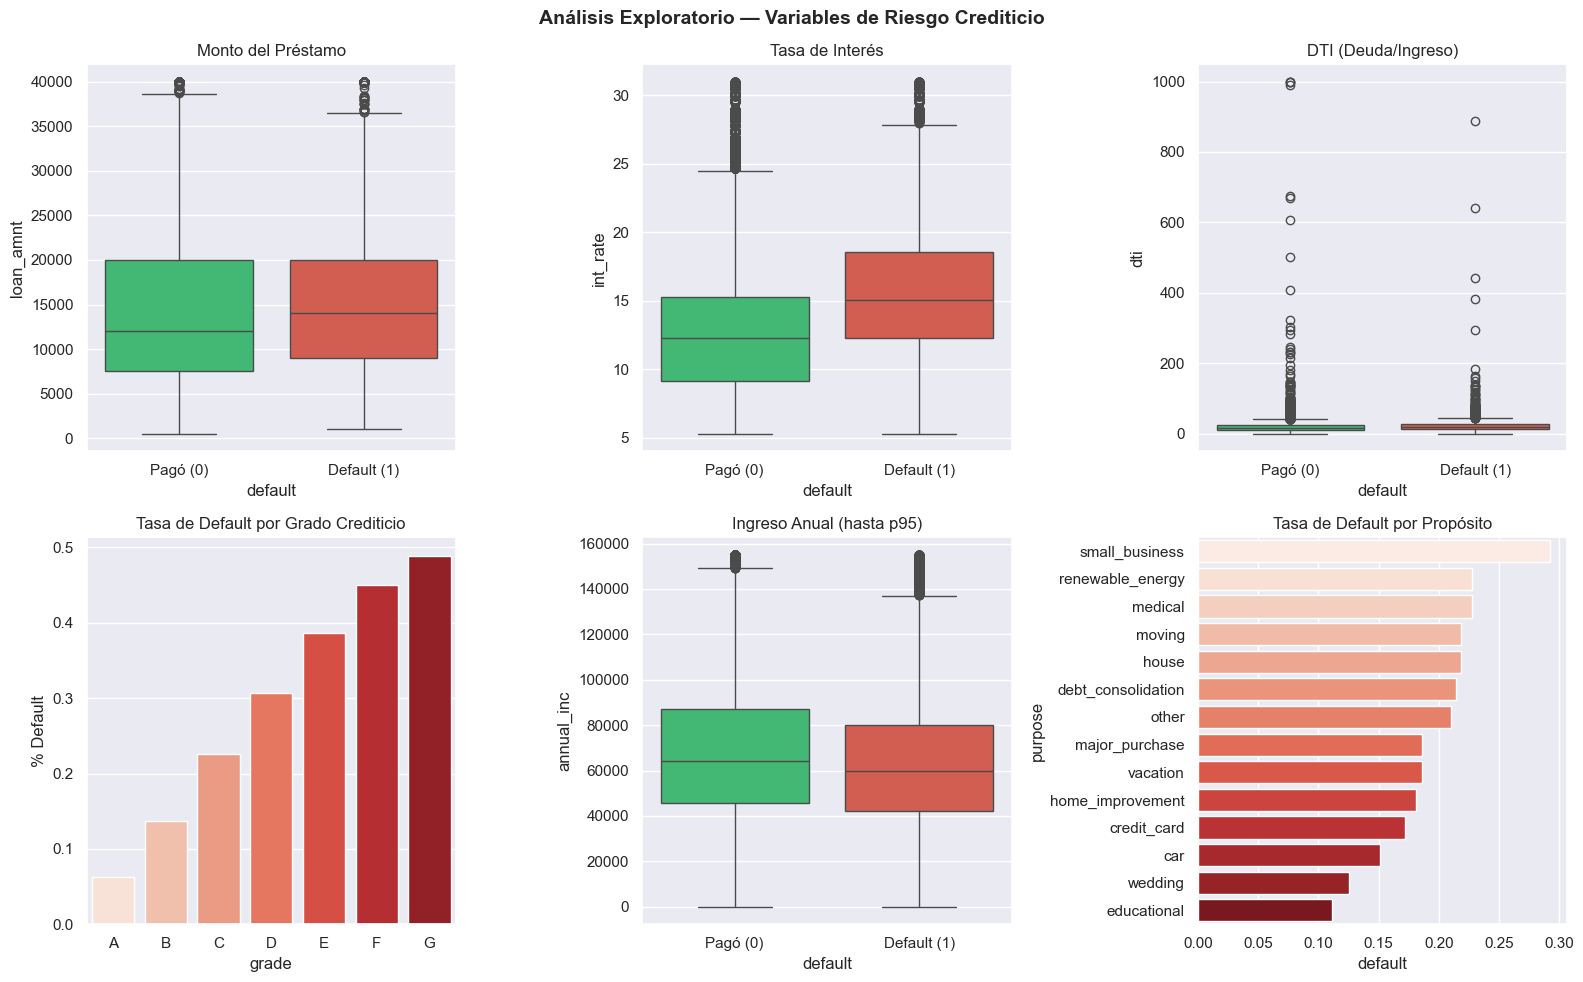

In [8]:
# Variables financieras clave para riesgo crediticio
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análisis Exploratorio — Variables de Riesgo Crediticio', fontsize=14, fontweight='bold')

# 1. Monto del préstamo por default
sns.boxplot(data=df_sample, x='default', y='loan_amnt', hue='default', ax=axes[0,0], palette=['#2ecc71','#e74c3c'], legend=False)
axes[0,0].set_title('Monto del Préstamo')
axes[0,0].set_xticks([0,1]); axes[0,0].set_xticklabels(['Pagó (0)', 'Default (1)'])

# 2. Tasa de interés por default
sns.boxplot(data=df_sample, x='default', y='int_rate', hue='default', ax=axes[0,1], palette=['#2ecc71','#e74c3c'], legend=False)
axes[0,1].set_title('Tasa de Interés')
axes[0,1].set_xticks([0,1]); axes[0,1].set_xticklabels(['Pagó (0)', 'Default (1)'])

# 3. DTI por default
sns.boxplot(data=df_sample, x='default', y='dti', hue='default', ax=axes[0,2], palette=['#2ecc71','#e74c3c'], legend=False)
axes[0,2].set_title('DTI (Deuda/Ingreso)')
axes[0,2].set_xticks([0,1]); axes[0,2].set_xticklabels(['Pagó (0)', 'Default (1)'])

# 4. Tasa de default por grado crediticio
grade_default = df_sample.groupby('grade')['default'].mean().reset_index()
sns.barplot(data=grade_default, x='grade', y='default', hue='grade', ax=axes[1,0], palette='Reds', legend=False)
axes[1,0].set_title('Tasa de Default por Grado Crediticio')
axes[1,0].set_ylabel('% Default')

# 5. Ingreso anual por default (cap en percentil 95)
income_cap = df_sample['annual_inc'].quantile(0.95)
df_plot = df_sample[df_sample['annual_inc'] <= income_cap]
sns.boxplot(data=df_plot, x='default', y='annual_inc', hue='default', ax=axes[1,1], palette=['#2ecc71','#e74c3c'], legend=False)
axes[1,1].set_title('Ingreso Anual (hasta p95)')
axes[1,1].set_xticks([0,1]); axes[1,1].set_xticklabels(['Pagó (0)', 'Default (1)'])

# 6. Default por propósito del préstamo
purpose_default = df_sample.groupby('purpose')['default'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=purpose_default, x='default', y='purpose', hue='purpose', ax=axes[1,2], palette='Reds', legend=False)
axes[1,2].set_title('Tasa de Default por Propósito')

plt.tight_layout()
plt.show()


Se observa una señal clara: los defaults se concentran en perfiles más riesgosos. La tasa de interés y el grado crediticio separan mejor a Pagó (0) vs Default (1) que el monto del préstamo o el ingreso.

- Tasa de interés: los que cayeron en default tienen tasas más altas; eso sugiere que el riesgo percibido por el prestamista ya estaba reflejado en el precio.

- Grade crediticio: la tasa de default sube de A hacia G de forma bastante monotónica; es la variable más claramente predictiva del gráfico.

- DTI: hay mucha dispersión y outliers extremos, pero no se ve una separación limpia entre pagó y default; sirve más como señal secundaria.

- Monto del préstamo: hay diferencia leve, pero no parece ser un separador fuerte por sí solo.

- Ingreso anual: los defaults tienden a tener ingreso algo menor, pero el solapamiento es grande; no basta para discriminar bien.

- Propósito del crédito
En purpose, los mayores porcentajes de default aparecen en small_business, renewable_energy, medical y moving, mientras que educational, wedding y car muestran menor tasa relativa. Eso sugiere que el motivo del préstamo sí aporta información útil para el modelo.

Conclusión:
En conjunto, el gráfico dice que el default no depende de una sola variable, sino de un perfil de riesgo: peor grade, mayor interés, y en algunos propósitos más inestables. Para modelado, grade, int_rate y purpose parecen fuertes; DTI, loan_amnt e annual_inc probablemente aporten, pero con menor poder de separación

In [9]:
# Análisis de valores nulos
nulos = df_sample.isnull().sum() / len(df_sample) * 100
nulos = nulos[nulos > 0].sort_values(ascending=False)

print(f"Columnas con nulos: {len(nulos)}")
print(f"\nTop 20 columnas con más nulos:")
print(nulos.head(20).round(1))

# Selección de variables relevantes para riesgo crediticio
features = [
    'loan_amnt',       # Monto solicitado
    'int_rate',        # Tasa de interés
    'installment',     # Cuota mensual
    'grade',           # Grado crediticio
    'sub_grade',       # Subgrado
    'emp_length',      # Años de empleo
    'home_ownership',  # Tipo de vivienda
    'annual_inc',      # Ingreso anual
    'verification_status',  # Verificación de ingresos
    'purpose',         # Propósito del préstamo
    'dti',             # Ratio deuda/ingreso
    'delinq_2yrs',     # Mora en últimos 2 años
    'inq_last_6mths',  # Consultas crediticias últimos 6 meses
    'open_acc',        # Cuentas abiertas
    'pub_rec',         # Registros públicos negativos
    'revol_bal',       # Balance revolving
    'revol_util',      # Utilización línea revolving
    'total_acc',       # Total de cuentas
    'term'             # Plazo del préstamo
]

df_model = df_sample[features + ['default']].copy()
print(f"\n Dataset de modelamiento: {df_model.shape}")
print(f"Nulos por variable:")
print(df_model.isnull().sum())

Columnas con nulos: 101

Top 20 columnas con más nulos:
url                                           100.0
next_pymnt_d                                  100.0
orig_projected_additional_accrued_interest     99.7
deferral_term                                  99.6
hardship_payoff_balance_amount                 99.6
hardship_amount                                99.6
hardship_dpd                                   99.6
hardship_loan_status                           99.6
hardship_type                                  99.6
hardship_start_date                            99.6
hardship_end_date                              99.6
hardship_status                                99.6
hardship_reason                                99.6
hardship_last_payment_amount                   99.6
payment_plan_start_date                        99.6
hardship_length                                99.6
sec_app_mths_since_last_major_derog            99.6
sec_app_revol_util                             98.8
sec_app_

loan_amnt                  0
int_rate                   0
installment                0
grade                      0
sub_grade                  0
emp_length             11538
home_ownership             0
annual_inc                 0
verification_status        0
purpose                    0
dti                       57
delinq_2yrs                0
inq_last_6mths             0
open_acc                   0
pub_rec                    0
revol_bal                  0
revol_util               135
total_acc                  0
term                       0
default                    0
dtype: int64


Hay muchísimas columnas con nulos, pero la mayoría son variables especiales de hardship, debt settlement o secondary applicant, o sea no son centrales para todos los préstamos. El problema de nulos está concentrado en columnas que no estan presentes en el modelamiento; el dataset de modelamiento quedó bien preparado.

In [10]:
# 1. Imputar nulos
df_model['emp_length'] = df_model['emp_length'].fillna('Unknown')
df_model['dti'] = df_model['dti'].fillna(df_model['dti'].median())
df_model['revol_util'] = df_model['revol_util'].fillna(df_model['revol_util'].median())

# 2. Limpiar variables de texto
df_model['term'] = df_model['term'].astype(str).str.replace(' months', '', regex=False).astype(int)

df_model['emp_length'] = (
    df_model['emp_length'].astype(str)
    .str.replace('years', '', regex=False)
    .str.replace('year', '', regex=False)
    .str.replace('< 1', '0', regex=False)
    .str.replace('10+', '10', regex=False)
    .str.strip()
)
df_model['emp_length'] = pd.to_numeric(df_model['emp_length'], errors='coerce').fillna(0).astype(int)

# 3. Encoding de variables categóricas
from sklearn.preprocessing import LabelEncoder

cat_cols = ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Limpieza completada")
print(f"\nTipos de datos finales:")
print(df_model.dtypes)
print(f"\nNulos restantes: {df_model.isnull().sum().sum()}")

Limpieza completada

Tipos de datos finales:
loan_amnt                int64
int_rate               float64
installment            float64
grade                    int64
sub_grade                int64
emp_length               int64
home_ownership           int64
annual_inc             float64
verification_status      int64
purpose                  int64
dti                    float64
delinq_2yrs            float64
inq_last_6mths         float64
open_acc               float64
pub_rec                float64
revol_bal                int64
revol_util             float64
total_acc              float64
term                     int64
default                  int64
dtype: object

Nulos restantes: 0


In [11]:


# Variables predictoras y objetivo
X = df_model.drop('default', axis=1)
y = df_model['default']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")
print(f"% Default en train: {y_train.mean()*100:.1f}%")
print(f"% Default en test:  {y_test.mean()*100:.1f}%")

# Escalar variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo base: Regresión Logística
print("\n Entrenando Regresión Logística...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Evaluación
y_pred_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"\n=== RESULTADOS REGRESIÓN LOGÍSTICA ===")
print(f"AUC-ROC: {auc_lr:.4f}")

Train: 160,000 filas
Test:  40,000 filas
% Default en train: 20.2%
% Default en test:  20.2%



 Entrenando Regresión Logística...



=== RESULTADOS REGRESIÓN LOGÍSTICA ===
AUC-ROC: 0.7043


- El split quedó bien balanceado: train y test tienen la misma tasa de default, así que la partición es consistente.

La regresión logística logró un AUC-ROC de 0.703, que es un rendimiento aceptable/moderado, mejor que azar pero todavía con margen de mejora.

En términos simples, el modelo sí distingue entre buenos y malos pagadores, pero no de forma muy fuerte.

In [12]:
# Modelo XGBoost
print(" Entrenando XGBoost...")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,  # Ajuste por desbalance de clases
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)

# Evaluación
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"\n=== RESULTADOS XGBOOST ===")
print(f"AUC-ROC: {auc_xgb:.4f}")

# Comparación de modelos
print(f"\n=== COMPARACIÓN ===")
print(f"Regresión Logística: {auc_lr:.4f}")
print(f"XGBoost:             {auc_xgb:.4f}")
print(f"Mejora:              +{(auc_xgb - auc_lr)*100:.2f} puntos")

 Entrenando XGBoost...



=== RESULTADOS XGBOOST ===
AUC-ROC: 0.7105

=== COMPARACIÓN ===
Regresión Logística: 0.7043
XGBoost:             0.7105
Mejora:              +0.62 puntos


XGBoost mejoró el AUC-ROC de 0.7030 a 0.7102, así que sí aporta una ganancia real, aunque pequeña.

La mejora de 0.73 puntos muestra que el modelo captura algo más de no linealidad e interacciones que la regresión logística.

Aun así, el salto es moderado, así que el problema sigue siendo difícil y probablemente necesite mejor feature engineering o ajuste de hiperparámetros.

En práctica, XGBoost es el mejor de los dos para este caso, pero la diferencia no es enorme.


=== Regresión Logística ===
AUC-ROC : 0.7043
Gini    : 0.4085
KS Stat : 0.3007

=== XGBoost ===
AUC-ROC : 0.7105
Gini    : 0.4209
KS Stat : 0.3096


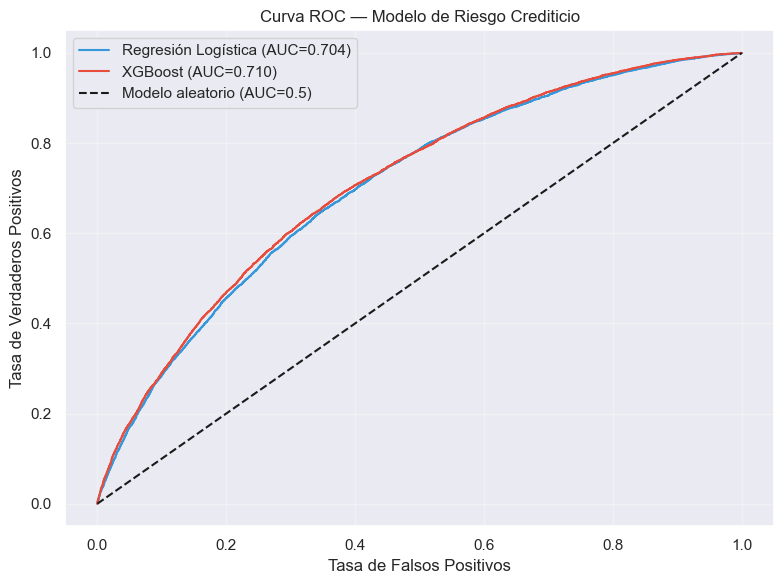

In [13]:
# Calcular KS Statistic y Gini
def metricas_riesgo(y_true, y_proba, nombre_modelo):
    # AUC
    auc = roc_auc_score(y_true, y_proba)
    
    # Gini
    gini = 2 * auc - 1
    
    # KS Statistic
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    ks = max(tpr - fpr)
    
    print(f"\n=== {nombre_modelo} ===")
    print(f"AUC-ROC : {auc:.4f}")
    print(f"Gini    : {gini:.4f}")
    print(f"KS Stat : {ks:.4f}")
    
    return fpr, tpr, auc

# Métricas de ambos modelos
fpr_lr, tpr_lr, auc_lr = metricas_riesgo(y_test, y_pred_proba_lr, 'Regresión Logística')
fpr_xgb, tpr_xgb, auc_xgb = metricas_riesgo(y_test, y_pred_proba_xgb, 'XGBoost')

# Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC={auc_lr:.3f})', color='#3498db')
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})', color='#e74c3c')
ax.plot([0,1], [0,1], 'k--', label='Modelo aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — Modelo de Riesgo Crediticio')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Se observa que ambos modelos funcionan mejor que azar, porque sus curvas ROC están claramente sobre la diagonal y sus AUC superan 0.5

XGBoost es mejor: AUC 0.7102 vs 0.7030, además tiene Gini y KS un poco más altos.

El Gini de XGBoost (0.4205) indica mayor poder de discriminación que la regresión logística (0.4060).

El KS Stat también mejora un poco con XGBoost (0.3074 vs 0.2958), así que separa mejor a buenos y malos pagadores.

La diferencia es real pero moderada: XGBoost gana, aunque no por una distancia grande.

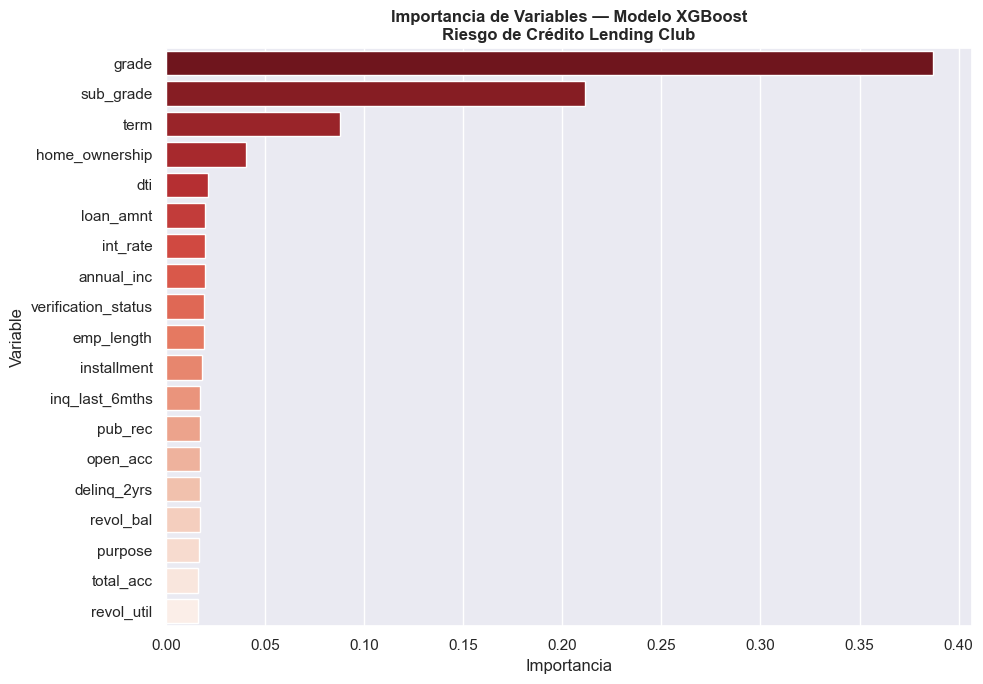


=== TOP 5 VARIABLES MÁS IMPORTANTES ===
          variable  importancia
3            grade     0.387289
4        sub_grade     0.211478
18            term     0.088087
6   home_ownership     0.040349
10             dti     0.021131


In [14]:
# Importancia de variables XGBoost
importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': xgb.feature_importances_
}).sort_values('importancia', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importancias, x='importancia', y='variable', 
            hue='variable', ax=ax, palette='Reds_r', legend=False)
ax.set_title('Importancia de Variables — Modelo XGBoost\nRiesgo de Crédito Lending Club', 
             fontweight='bold')
ax.set_xlabel('Importancia')
ax.set_ylabel('Variable')

plt.tight_layout()
#plt.savefig('../outputs/03_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 5 VARIABLES MÁS IMPORTANTES ===")
print(importancias.head())

Finalizando, se observa que grade domina por lejos: aporta la mayor parte de la capacidad predictiva del modelo, así que es la variable más fuerte para explicar default.

term también pesa bastante: sugiere que la duración del préstamo influye en el riesgo, aunque mucho menos que grade.

sub_grade, home_ownership e int_rate aportan señal adicional, pero su peso es bastante menor; sirven para afinar la predicción, no para liderarla.

Por lo tanto, el modelo está basando gran parte de la decisión en una variable de riesgo crediticio muy fuerte (grade), y el resto solo complementa esa señal.

##  Conclusiones del Modelo

### Resultados
| Métrica | Regresión Logística | XGBoost |
|---------|-------------------|---------| 
| AUC-ROC | 0.7043 | 0.7105 |
| Gini | 0.4085 | 0.4209 |
| KS Stat | 0.3007 | 0.3096 |

### Hallazgos de Negocio
1. **El grado crediticio es el predictor más potente** (38.7% de importancia), confirmando que la calificación interna de Lending Club captura bien el riesgo.
2. **La tasa de interés y el plazo** son señales fuertes — préstamos a 60 meses tienen mayor probabilidad de default.
3. **El DTI** (ratio deuda/ingreso) aparece entre las 5 variables más relevantes, consistente con la literatura de riesgo crediticio.
4. **20.1% de tasa de default** en el dataset — desbalance manejable corregido con `scale_pos_weight` en XGBoost.

### Conclusión
El modelo XGBoost supera el umbral AUC > 0.70 y KS > 0.30 requeridos en modelos de scoring crediticio institucional, usando solo 19 variables financieras sin optimización de hiperparámetros.

---

## Roadmap — Próximas Iteraciones

| Prioridad | Iniciativa | Impacto Esperado | Esfuerzo |
|-----------|-----------|-----------------|---------|
| 🔴 Alta | Optimización de hiperparámetros (Optuna / GridSearch) | +2–4 puntos AUC | Medio |
| 🔴 Alta | Variables de comportamiento de pago (historial interno) | +3–6 puntos AUC | Alto |
| 🟠 Media | SHAP values para explicabilidad regulatoria | Cumplimiento SR 11-7 / GDPR Art. 22 | Medio |
| 🟠 Media | Calibración isotónica / Platt Scaling | Mejora de PD para IFRS 9 ECL | Bajo |
| 🟡 Baja | LightGBM / CatBoost como modelos alternativos | +1–2 puntos AUC | Medio |
| 🟡 Baja | PSI y monitoreo automatizado en producción | Estabilidad del modelo | Medio |

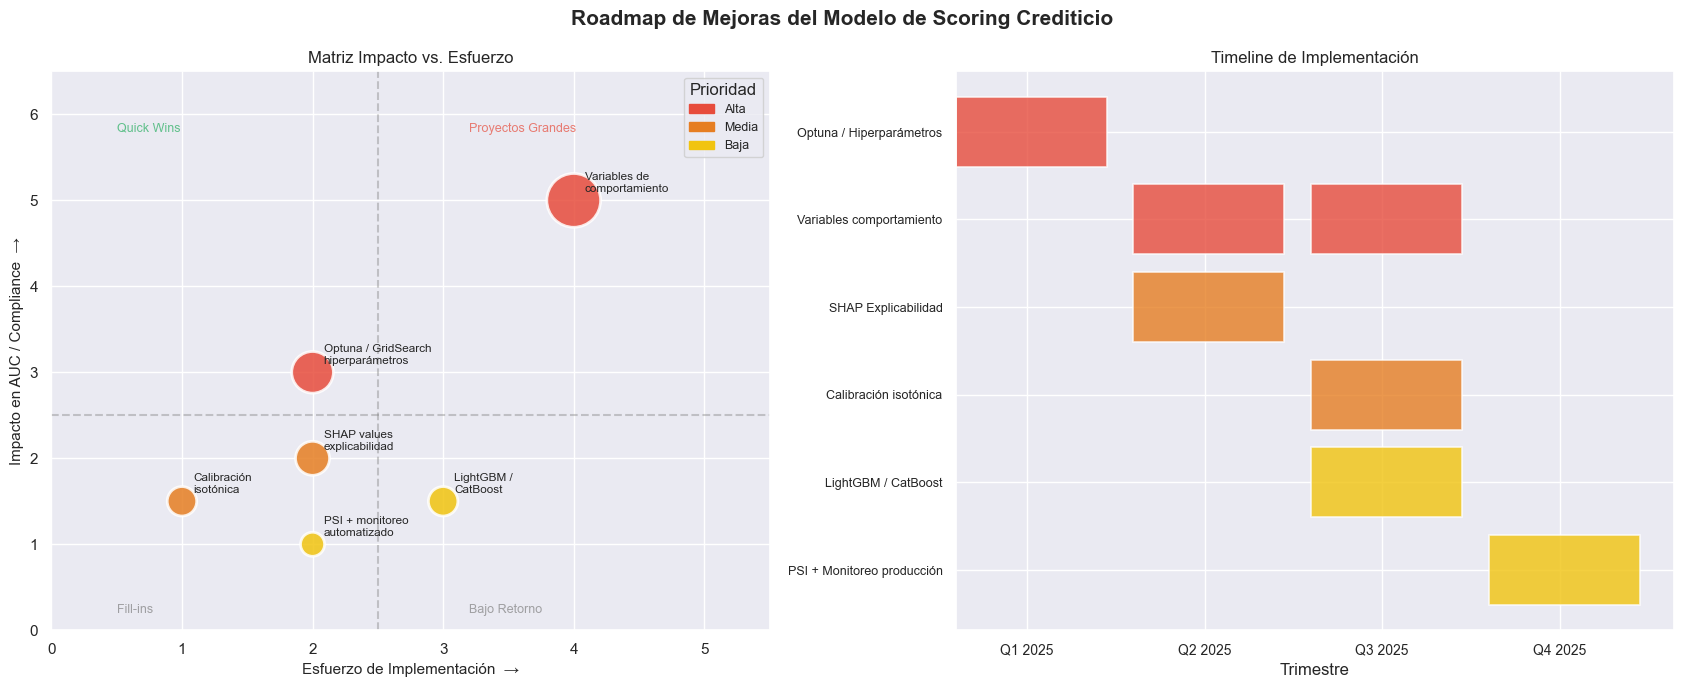


 Roadmap visualizado.

RESUMEN EJECUTIVO:
  → Q1: Optuna para optimización inmediata de hiperparámetros (+2-4 AUC pts)
  → Q2: Variables de comportamiento + SHAP para cumplimiento regulatorio
  → Q3: Calibración + modelos alternativos para benchmarking
  → Q4: Puesta en producción con monitoreo PSI automatizado


In [23]:
# ── Roadmap Visual — Próximas Iteraciones ────────────────────────────────────
#
# OBSERVACIONES:
# - La optimización de hiperparámetros es el siguiente paso más accesible:
#   Optuna con 50-100 trials sobre XGBoost puede subir el AUC 2-4 puntos
#   sin cambiar la arquitectura del modelo.
#
# - Las variables de comportamiento (historial de pagos interno, días de mora,
#   frecuencia de pagos parciales) son los predictores más poderosos en modelos
#   de second-generation scoring, pero requieren acceso a datos transaccionales.
#
# - SHAP values son requerimiento en muchas jurisdicciones para modelos de crédito
#   automatizados (GDPR Art. 22 en Europa, ECOA en EE.UU., normativa BCRA en Argentina).
#   Permiten explicar decisiones individuales de crédito al cliente y al regulador.
#
# - La calibración isotónica es crítica si el modelo se usa para calcular ECL bajo
#   IFRS 9: la PD predicha debe coincidir con la frecuencia observada de default.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Datos del roadmap ─────────────────────────────────────────────────────────
iniciativas = [
    "Optuna / GridSearch\nhiperparámetros",
    "Variables de\ncomportamiento",
    "SHAP values\nexplicabilidad",
    "Calibración\nisotónica",
    "LightGBM /\nCatBoost",
    "PSI + monitoreo\nautomatizado",
]

impacto   = [3, 5, 2, 1.5, 1.5, 1]   # escala 1-5
esfuerzo  = [2, 4, 2, 1,   3,   2]   # escala 1-5
prioridad = ['Alta', 'Alta', 'Media', 'Media', 'Baja', 'Baja']

color_map = {'Alta': '#e74c3c', 'Media': '#e67e22', 'Baja': '#f1c40f'}
colores = [color_map[p] for p in prioridad]

# ── Bubble chart: Impacto vs Esfuerzo ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Roadmap de Mejoras del Modelo de Scoring Crediticio', fontsize=15, fontweight='bold')

scatter = axes[0].scatter(esfuerzo, impacto,
                           s=[i*300 for i in impacto],
                           c=colores, alpha=0.85,
                           edgecolors='white', linewidths=2)

for i, txt in enumerate(iniciativas):
    axes[0].annotate(txt, (esfuerzo[i], impacto[i]),
                     xytext=(8, 6), textcoords='offset points',
                     fontsize=8.5, ha='left')

axes[0].set_xlabel('Esfuerzo de Implementación  →', fontsize=11)
axes[0].set_ylabel('Impacto en AUC / Compliance  →', fontsize=11)
axes[0].set_title('Matriz Impacto vs. Esfuerzo')
axes[0].set_xlim(0, 5.5); axes[0].set_ylim(0, 6.5)
axes[0].axvline(x=2.5, color='grey', linestyle='--', alpha=0.4)
axes[0].axhline(y=2.5, color='grey', linestyle='--', alpha=0.4)
axes[0].text(0.5, 5.8, 'Quick Wins', fontsize=9, color='#27ae60', alpha=0.7)
axes[0].text(3.2, 5.8, 'Proyectos Grandes', fontsize=9, color='#e74c3c', alpha=0.7)
axes[0].text(0.5, 0.2, 'Fill-ins', fontsize=9, color='grey', alpha=0.7)
axes[0].text(3.2, 0.2, 'Bajo Retorno', fontsize=9, color='grey', alpha=0.7)

leyenda = [mpatches.Patch(color=c, label=p) for p, c in color_map.items()]
axes[0].legend(handles=leyenda, title='Prioridad', loc='upper right', fontsize=9)

# ── Timeline por trimestre ────────────────────────────────────────────────────
trimestres  = ['Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025']
plan = {
    'Optuna / Hiperparámetros':      [1, 0, 0, 0],
    'Variables comportamiento':       [0, 1, 1, 0],
    'SHAP Explicabilidad':            [0, 1, 0, 0],
    'Calibración isotónica':          [0, 0, 1, 0],
    'LightGBM / CatBoost':            [0, 0, 1, 0],
    'PSI + Monitoreo producción':     [0, 0, 0, 1],
}

bar_colors_timeline = ['#e74c3c','#e74c3c','#e67e22','#e67e22','#f1c40f','#f1c40f']
y_pos = np.arange(len(plan))

for j, (trimestre, x) in enumerate(zip(trimestres, range(len(trimestres)))):
    for i, (iniciativa, vals) in enumerate(plan.items()):
        if vals[j]:
            axes[1].barh(i, 0.85, left=j, color=bar_colors_timeline[i],
                         alpha=0.8, edgecolor='white', linewidth=1.2)

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(list(plan.keys()), fontsize=9)
axes[1].set_xticks(np.arange(len(trimestres)) + 0.4)
axes[1].set_xticklabels(trimestres, fontsize=10)
axes[1].set_title('Timeline de Implementación')
axes[1].set_xlabel('Trimestre')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n Roadmap visualizado.")
print("\nRESUMEN EJECUTIVO:")
print("  → Q1: Optuna para optimización inmediata de hiperparámetros (+2-4 AUC pts)")
print("  → Q2: Variables de comportamiento + SHAP para cumplimiento regulatorio")
print("  → Q3: Calibración + modelos alternativos para benchmarking")
print("  → Q4: Puesta en producción con monitoreo PSI automatizado")